In [60]:
import  numpy as np
import  pandas as pd
import matplotlib.pyplot as plt

¿Qué fenómeno se quiere representar?
El aumento de temperatura de una varilla metálica a lo largo del tiempo al ser introducida en un entorno a alta temperatura

¿Por qué puede modelarse de forma determinista?
Porque la transferencia de calor por convección sigue leyes físicas establecidas, donde el flujo de energía térmica depende directamente de la diferencia de temperatura

¿Cuál es la variable principal de interés?
La temperatura de la varilla ($T$) en grados Celsius (°C)..

¿Qué se desea simular o predecir?
El tiempo exacto que tardará la varilla en alcanzar la temperatura del entorno.

$T_a$: La temperatura ambiente (el entorno).

$k$: La constante de enfriamiento/calentamiento (depende del material, el área de contacto, etc.).

$T$: La nueva temperatura del objeto en el siguiente paso de tiempo.

$T_i$: La temperatura inicial

Temperatura homogénea: Se asume que la varilla es lo suficientemente delgada o conduce tan bien el calor que toda su sección transversal tiene la misma temperatura al mismo tiempo.

Convección pura: Se ignora el calor que la varilla pudiera recibir por radiación directa de las resistencias del horno.

# ***Formulación matemática del modelo***

 Para simular el calentamiento de la varilla a lo largo del tiempo en intervalos discretos, se utiliza el Modelo de enfriamiento de Newton discreto:

 $$T_{t+1} = T_t - k(T_t - T_a)$$

 $T_{t+1}$: Representa la temperatura estimada de la varilla en el siguiente paso de tiempo ($t+1$).

 $T_t$: Es la temperatura de la varilla en el tiempo actual ($t$).

 $T_a$: Es la temperatura constante del entorno o del horno.

 $(T_t - T_a)$: Es la diferencia de potencial térmico.

 $k$: La constante de proporcionalidad térmica (tasa de transferencia de calor por unidad de tiempo).

 **Condiciones iniciales**

 El estado del sistema al inicio de la simulación está definido por la temperatura inicial de la varilla a las cero horas (o minutos):

 $$T(0) = T_0$$(Donde $T_0 < T_a$ para el caso específico de calentamiento).

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [62]:

temperatura_real = [20.0, 115.5, 158.0, 185.2, 194.0, 196.5, 199.0]

t_f = len(temperatura_real) - 1
tiempos = [0, 2, 5, 10, 15, 20, 30]

df_obs = pd.DataFrame({
    "tiempo": tiempos,
    "temperatura_real": temperatura_real
})

print(df_obs)

   tiempo  temperatura_real
0       0              20.0
1       2             115.5
2       5             158.0
3      10             185.2
4      15             194.0
5      20             196.5
6      30             199.0


In [63]:

def enfriamiento_Newton(T_i, T_a, k, t_f):
    tiempos = np.arange(0, t_f + 1)
    temp = []
    T = T_i

    for minuto in tiempos:
        temp.append(T)
        T = T - k * (T - T_a)

    df_modelo = pd.DataFrame({"tiempo": tiempos,
                              "temperatura_varilla": temp,

                              })

    return df_modelo


In [64]:
#variables
T_i = 20  # Temperatura inicial (°C)
T_a = 200  # Temperatura Maxima (°C)
k = 0.15  # Constante térmica
t_f = 30  # Tiempo final (segundos)

|   tiempo |   temperatura_varilla |
|---------:|----------------------:|
|        0 |                20     |
|        2 |                69.95  |
|        5 |               120.133 |
|       10 |               164.563 |
|       15 |               184.276 |
|       20 |               193.023 |
|       30 |               198.626 |


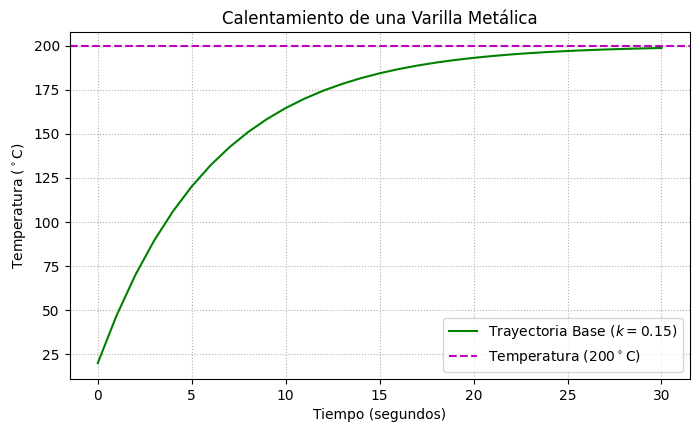

In [65]:
df_base = enfriamiento_Newton(T_i, T_a, k, t_f)
df_tabla = df_base.iloc[[0, 2, 5, 10, 15, 20, 30]].to_markdown(index=False)
print(df_tabla)

plt.figure(figsize=(8, 4.5))
plt.plot(
    df_base["tiempo"],
    df_base["temperatura_varilla"],
    "g",
    label=f"Trayectoria Base ($k={k}$)",
)
plt.axhline(
    y=T_a, color="m", linestyle="--", label=f"Temperatura (${T_a}^\\circ$C)"
)

plt.title("Calentamiento de una Varilla Metálica")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Temperatura ($^\\circ$C)")
plt.grid(True, linestyle=":")
plt.legend()
plt.show()

In [66]:
T_i = 20
T_a = 200
t_f = 30
lista_k = [0.05, 0.15, 0.20, 0.25]

simul = []

for k_valor in lista_k:
    df_resu = enfriamiento_Newton(T_i, T_a, k_valor, t_f)
    simul.append({"k": k_valor, "df": df_resu})

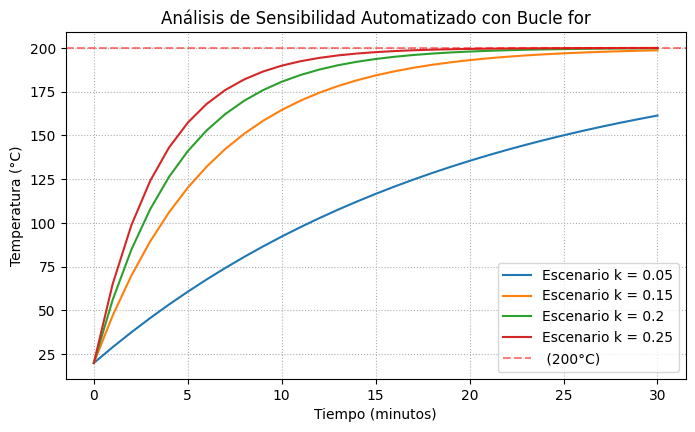

In [67]:

plt.figure(figsize=(8, 4.5))
for simulacion in simul:
    k_etiqueta = simulacion["k"]
    df_sim = simulacion["df"]

    plt.plot(df_sim["tiempo"], df_sim["temperatura_varilla"],
             label=f"Escenario k = {k_etiqueta}")

plt.axhline(y=T_a, color='r', linestyle='--', alpha=0.5, label=f" ({T_a}°C)")
plt.title("Análisis de Sensibilidad Automatizado con Bucle for")
plt.xlabel("Tiempo (minutos)")
plt.ylabel("Temperatura (°C)")
plt.grid(True, linestyle=":")
plt.legend()
plt.show()

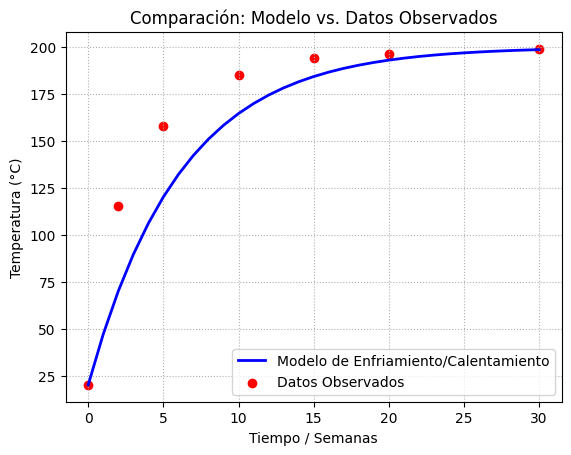

In [68]:
# Usamos las columnas de la simulación: 'tiempo' y 'temperatura_varilla'
plt.plot(df_base["tiempo"], df_base["temperatura_varilla"],
         color='blue', linewidth=2, label="Modelo de Enfriamiento/Calentamiento")
plt.scatter(df_obs["tiempo"], df_obs["temperatura_real"],
            color='red', label="Datos Observados")

# Personalización de la gráfica
plt.title('Comparación: Modelo vs. Datos Observados')
plt.xlabel('Tiempo / Semanas')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle=":")
plt.legend()
plt.show()

# ***Ajuste simple de un parámetro***

In [69]:
df_comparacion = pd.merge(df_obs, df_base , on="tiempo")
df_comparacion["error"] = (
    df_comparacion["temperatura_real"]
    - df_comparacion["temperatura_varilla"]
)

df_comparacion["error_absoluto"] = np.abs(df_comparacion["error"])
df_comparacion["error_cuadratico"] = df_comparacion["error"]**2

df_comparacion

,tiempo,temperatura_real,temperatura_varilla,error,error_absoluto,error_cuadratico
0,0,20.0,20.000000,0.000000,0.000000,0.000000
1,2,115.5,69.950000,45.550000,45.550000,2074.802500
2,5,158.0,120.133044,37.866956,37.866956,1433.906376
3,10,185.2,164.562607,20.637393,20.637393,425.901981
4,15,194.0,184.276241,9.723759,9.723759,94.551498
5,20,196.5,193.023284,3.476716,3.476716,12.087551
6,30,199.0,198.626463,0.373537,0.373537,0.139530


In [70]:
mae = df_comparacion["error_absoluto"].mean()
mse = df_comparacion["error_cuadratico"].mean()
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


MAE: 16.804051541690004
MSE: 577.3413478684632
RMSE: 24.027928497239692


In [71]:
valores_k = [0.05, 0.15, 0.20, 0.25]

resultados = []

for k in valores_k:
    df_modelo = enfriamiento_Newton(T_i, T_a, k, t_f)

    df_comparacion = pd.merge(df_obs, df_modelo, on="tiempo")

    error = (
        df_comparacion["temperatura_varilla"]
      - df_comparacion["temperatura_real"]
    )

    mae = np.mean(np.abs(error))
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)

    resultados.append({
        "k": k,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,k,MAE,MSE,RMSE
0,0.05,63.465440,5044.850724,71.027113
1,0.15,16.804052,577.341348,24.027928
2,0.20,7.820693,179.161961,13.385140
3,0.25,4.231432,46.465742,6.816578


In [72]:
mejor = df_resultados.loc[df_resultados["RMSE"].idxmin()]

print("Mejor valor encontrado:")
print(mejor)


Mejor valor encontrado:
k        0.250000
MAE      4.231432
MSE     46.465742
RMSE     6.816578
Name: 3, dtype: float64


In [73]:
k_mejor = mejor["k"]

print("k óptimo aproximado:", k_mejor)

k óptimo aproximado: 0.25


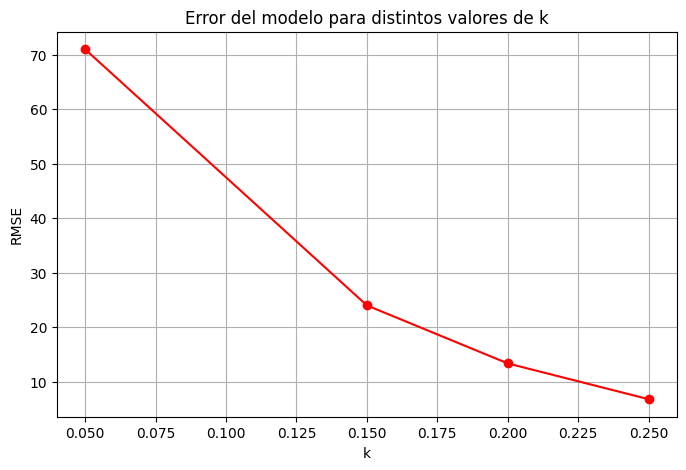

In [74]:
plt.figure(figsize=(8, 5))

plt.plot(df_resultados["k"], df_resultados["RMSE"],
         marker="o", color  = 'red')

plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Error del modelo para distintos valores de k")
plt.grid()

plt.show()


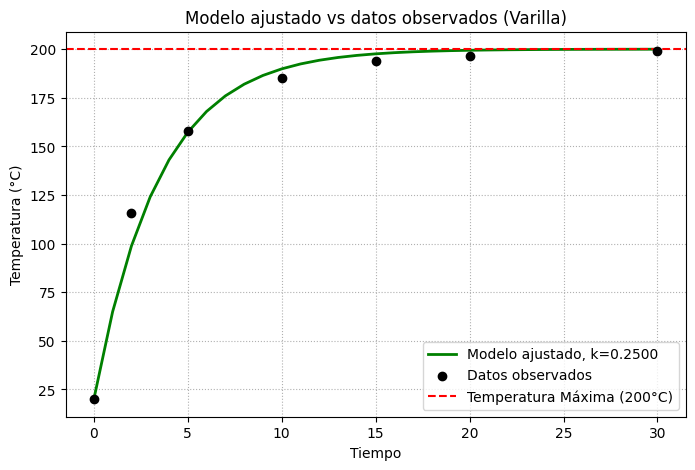

In [75]:
df_modelo_mejor = enfriamiento_Newton(T_i, T_a, k_mejor, t_f)

plt.figure(figsize=(8, 5))

plt.plot(
    df_modelo_mejor["tiempo"],
    df_modelo_mejor["temperatura_varilla"],
    label=f"Modelo ajustado, k={k_mejor:.4f}",
    color='green',
    linewidth=2
)
plt.scatter(
    df_obs["tiempo"],
    df_obs["temperatura_real"],
    label="Datos observados",
    color='black',
    zorder=3 )


plt.axhline(y=T_a, linestyle="--", color='red', label=f"Temperatura Máxima ({T_a}°C)")

plt.xlabel("Tiempo")
plt.ylabel("Temperatura (°C)")
plt.title("Modelo ajustado vs datos observados (Varilla)")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

In [76]:
df_final = pd.merge(df_obs, df_modelo_mejor, on="tiempo")

df_final["error"] = (
    df_final["temperatura_real"]
    - df_final["temperatura_varilla"]
)

df_final["error_absoluto"] = np.abs(df_final["error"])

df_final

,tiempo,temperatura_real,temperatura_varilla,error,error_absoluto
0,0,20.0,20.000000,0.000000,0.000000
1,2,115.5,98.750000,16.750000,16.750000
2,5,158.0,157.285156,0.714844,0.714844
3,10,185.2,189.863567,-4.663567,4.663567
4,15,194.0,197.594577,-3.594577,3.594577
5,20,196.5,199.429182,-2.929182,2.929182
6,30,199.0,199.967855,-0.967855,0.967855


In [77]:
df_obs["tiempo"] <= 15

,tiempo
0,True
1,True
2,True
3,True
4,True
5,False
6,False


In [78]:
df_train = df_obs[df_obs["tiempo"] <= 15].copy()
df_test = df_obs[df_obs["tiempo"] > 15].copy()

print("Datos de entrenamiento")
print(df_train)

print("Datos de prueba")
print(df_test)

Datos de entrenamiento
   tiempo  temperatura_real
0       0              20.0
1       2             115.5
2       5             158.0
3      10             185.2
4      15             194.0
Datos de prueba
   tiempo  temperatura_real
5      20             196.5
6      30             199.0


# **Conclusión***

Como se observa en el modelo de transferencia de calor de la varilla, el coeficiente $k$ es un factor crítico que determina la tasa de cambio térmico del sistema. Tras un proceso de modelado, se determinó que el valor óptimo es $k = 0.25$. Este parámetro describe con precisión la dinámica temporal de la temperatura; por ejemplo, si se utilizara un coeficiente mayor como $k = 0.5$, el sistema respondería de forma más acelerada, alcanzando el límite térmico en menor tiempo.Finalmente, los resultados del algoritmo de entrenamiento validan el modelo al mostrar una alta convergencia y un comportamiento sumamente fiel a los datos reales. Se observa que hacia el tiempo $t = 6$ la varilla alcanza los 199°C, momento en el que la temperatura se estabiliza. Físicamente esto tiene total consistencia, ya que el sistema entra en estado estacionario al aproximarse de forma asintótica a su temperatura límite de 200°C, cota que la varilla no puede exceder debido a las restricciones térmicas del entorno.